# Load intro stuff

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packa

In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
# VLA k band 9 mm (ish)
all_bands    = ["Band 4 nterms2",  "Band 5", "Band 5 robust -1",     "Band 6", "Band 7 nterms2"]
bands_naming = ['Band4_nterms2',   'Band5',  "Band5_robust_minus1",  'Band6',  'Band7_nterms2']
bands_labels = ['Band 4',          'Band 5', "Band 5 robust -1",      'Band 6', 'Band 7']

In [4]:
df_POLF = load_POLF(all_bands, print_things = True)

Band = Band 4 nterms2
Band = Band 5
Band = Band 5 robust -1
Band = Band 6
Band = Band 7 nterms2
 in load_POLF, results = {'Band': ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2'], 'POLF_Gaussian': [1.1877280000000001, 0.9329613999999999, 1.3769860999999999, 1.4453122, 0.8302132], 'POLF_maxPOLI': [1.561384, 1.0520775, 1.5137895000000001, 1.4862873, 1.0841521], 'POLF_maxStokesI': [1.3677061000000001, 0.9908963, 1.4034492, 1.4639224, 1.0421403]}


In [5]:
df_POLF

,Band,POLF_Gaussian,POLF_maxPOLI,POLF_maxStokesI,POLF_mean
0,Band 4 nterms2,1.187728,1.561384,1.367706,1.372273
1,Band 5,0.932961,1.052077,0.990896,0.991978
2,Band 5 robust -1,1.376986,1.513790,1.403449,1.431408
3,Band 6,1.445312,1.486287,1.463922,1.465174
4,Band 7 nterms2,0.830213,1.084152,1.042140,0.985502


# Make Curves

In [ ]:
MakeCurves('v5', f_values, minn, maxx, N, lambda_bands_cm, bands_naming)

In [ ]:
# Make some empty arrays for stuff

a_dist_micron = {}
P_times_omega = {}
best_a_max = {}
POLF_obs = {}
best_sf = {}
best_idx_arr = {}
P_times_omega = {}


# Loop over f values and csv files
for f, fname in csv_files.items():

    df = pd.read_csv(path  + fname)

    # x-axis
    a_max_vals = df["Xdata"].values
    a_dist_micron[f] = a_max_vals

    # ALL bands
    Pw = np.column_stack([
        df[f"P_times_omega_{b}"].values for b in bands_naming
    ])
    P_times_omega[f] = Pw


    sf_medians, best_idx = STDEV_Calculations(a_max_vals, Pw, fit_indices, POLF_obs_all)




    best_a_max[f] = a_max_vals[best_idx]
    best_sf[f] = sf_medians[best_idx]
    best_idx_arr[f] = best_idx
    POLF_obs[f] = np.array([
    POLF_obs_all[band_to_index[b]] for b in all_bands
])

# Choose porosity values we want to test

In [6]:
f_values = [1, 0.75, 0.5, 0.25]

csv_files = {
    1:   "P_omega_vs_amax_1_CustomBounds_JUST_AMAX_POSTER.csv",
    0.75:   "P_omega_vs_amax_0_75_CustomBounds_JUST_AMAX_POSTER.csv",
    0.5:   "P_omega_vs_amax_0_5_CustomBounds_JUST_AMAX_POSTER.csv",
    0.25:   "P_omega_vs_amax_0_25_CustomBounds_JUST_AMAX_POSTER.csv",
}

# Find the scaling factor

In [7]:
df_POLF

,Band,POLF_Gaussian,POLF_maxPOLI,POLF_maxStokesI,POLF_mean
0,Band 4 nterms2,1.187728,1.561384,1.367706,1.372273
1,Band 5,0.932961,1.052077,0.990896,0.991978
2,Band 5 robust -1,1.376986,1.513790,1.403449,1.431408
3,Band 6,1.445312,1.486287,1.463922,1.465174
4,Band 7 nterms2,0.830213,1.084152,1.042140,0.985502


In [8]:
POLF_type = 'max Stokes I'
plot_sf = 1.5

POLF_obs_for_plot = dict(zip(df_POLF["Band"], df_POLF["POLF_maxStokesI"]))
POLF_obs_for_plot

{'Band 4 nterms2': 1.3677061000000001,
 'Band 5': 0.9908963,
 'Band 5 robust -1': 1.4034492,
 'Band 6': 1.4639224,
 'Band 7 nterms2': 1.0421403}

# Plot for all porosity values

In [9]:
bands_fit = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]



a_max_dist_micron_all, P_times_omega_all, a_max_best_all, POLF_obs_all, best_sf_all, best_idx_all, chi_sq_all = find_sf_v4(
    all_bands,
    bands_naming,
    bands_fit,
    csv_files,
    P_omega_data_folder_path,
    df_POLF,
    POLF_type,
    print_results=True
)



The Bands we are looking at are: ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
Best idx: {1: 384, 0.75: 462, 0.5: 568, 0.25: 750}
Best a_max: {1: 165.0, 0.75: 211.0, 0.5: 280.0, 0.25: 953.4463569226156}
Best SF: {1: 1.8458669521770532, 0.75: 1.6580979002270437, 0.5: 1.590315393697586, 0.25: 1.6688667942896076}
Best chi^2: {1: 0.01187235609229597, 0.75: 0.0010838879970225864, 0.5: 0.0005214416114313072, 0.25: 0.061025641167537684}


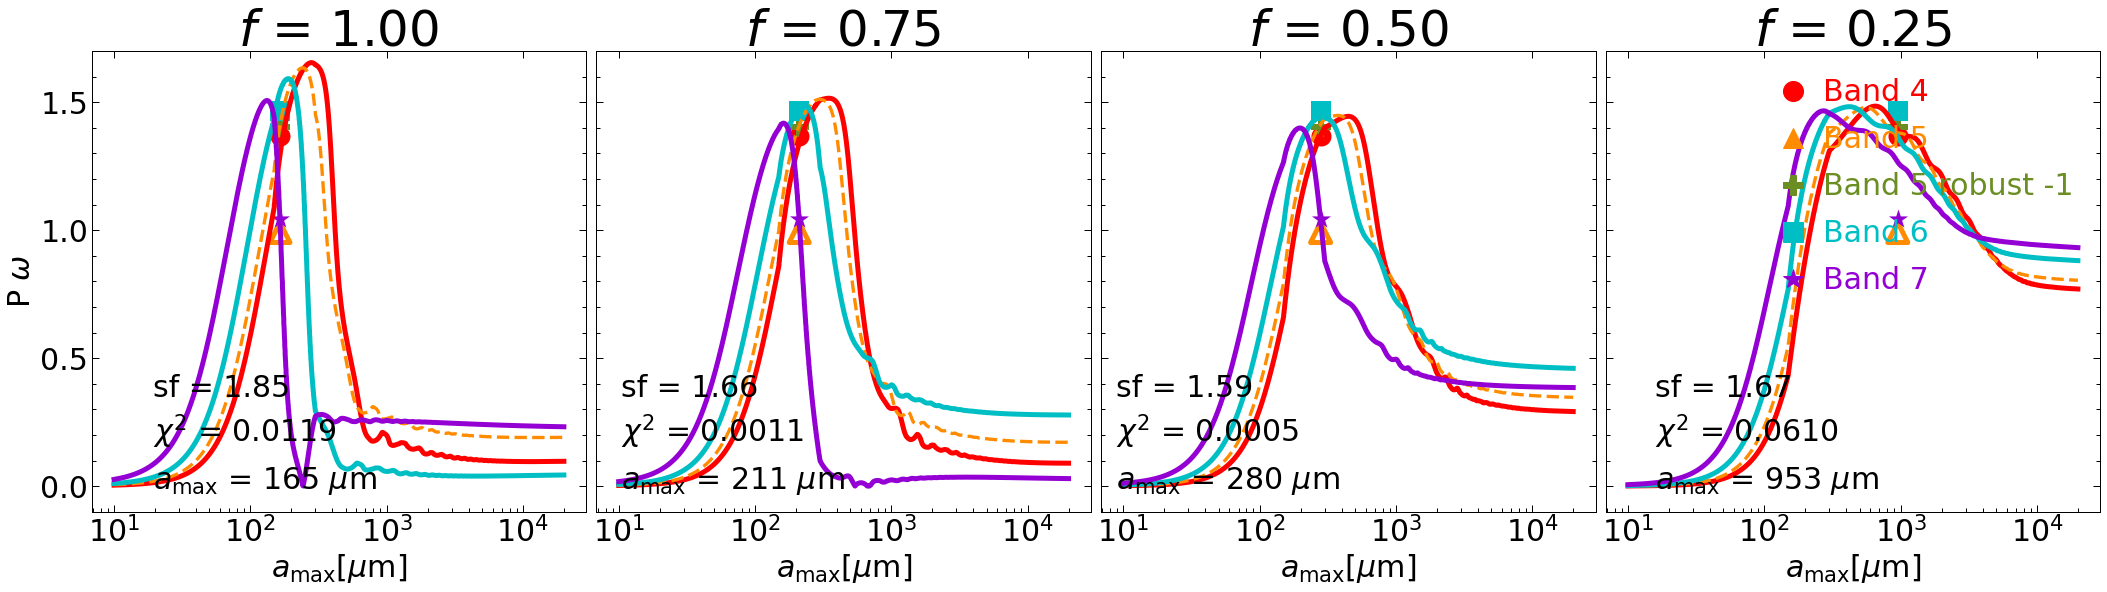

In [10]:
fig, ax = plot_scale_factor_results_JUST_AMAX(all_bands, 
                                    bands_labels, 
                                    bands_fit, 
                                    f_values,                               
                                    a_max_dist_micron_all, 
                                    P_times_omega_all,
                                    best_sf_all, 
                                    best_idx_all, 
                                    a_max_best_all,
                                    POLF_obs_for_plot,
                                    chi_sq_all,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                    chi_sq_precision = 4)
# Plot lines so I can see if its correct 
plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_AllBands.pdf", 
            dpi=300, 
            bbox_inches='tight')

In [11]:
# raise SystemExit("Stop here")

Target poster size = (49.8, 12.15) cm
figx, figy = (27.570, 6.727)
(13784, 3363)


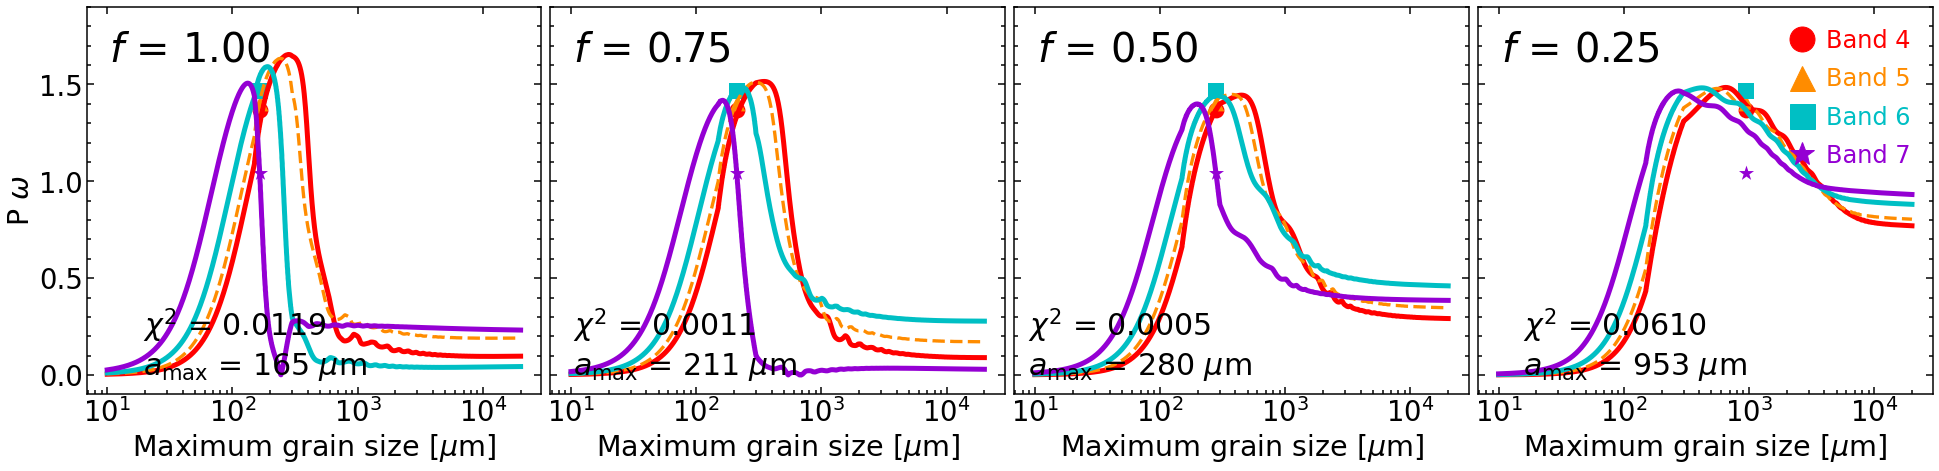

In [22]:
# Desired final size on poster
poster_x_cm = constants.poster_refx
poster_y_cm = constants.poster_refy

print(rf"Target poster size = ({poster_x_cm}, {poster_y_cm}) cm")

# Calibration from your original test
calib_figx = 30
calib_figy = 8

calib_slides_x_cm = 54.19
calib_slides_y_cm = 14.45

# Convert poster size -> matplotlib figsize
figx = calib_figx * poster_x_cm / calib_slides_x_cm
figy = calib_figy * poster_y_cm / calib_slides_y_cm

print(rf"figx, figy = ({figx:.3f}, {figy:.3f})")

poster_bands_labels = ['Band 4',   "Band 5 robust -1",      'Band 6', 'Band 7']

# --------------------------------------------------------------------------------------
fig, ax = plot_scale_factor_results_JUST_AMAX(all_bands, 
                                    bands_labels, 
                                    bands_fit, 
                                    f_values,                               
                                    a_max_dist_micron_all, 
                                    P_times_omega_all,
                                    best_sf_all, 
                                    best_idx_all, 
                                    a_max_best_all, 
                                    POLF_obs_for_plot,
                                              chi_sq_all,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                    chi_sq_precision = 4,
                                    for_poster = True,
                                  #f_fs = 45, 
                                   # f_x = 0.05, f_y = 0.9,
                                   fig_x = figx, fig_y = figy,
                                   plot_sf = 1,
                                   ymax = 1.9,
                                   f_y = 0.86,
                                   spine_width = poster_spine_width)

# ax[0].axvline(165)
# ax[2].axvline(268)

# Hardcode lines to check
# ax[0].axvline(165, lw = 5, color = 'black')
# ax[1].axvline(211, lw = 5, color = 'black')
# ax[2].axvline(280, lw = 5, color = 'black')
# ax[3].axvline(953, lw = 5, color = 'black')

# Plot lines so I can see if its correct 
plt.savefig(image_folder_path + '/POSTER/' + "DustModelPlot_AllBands.png", 
            dpi=500, 
          #  bbox_inches='tight',
               facecolor='white')

from PIL import Image

img = Image.open(image_folder_path + '/POSTER/' + "DustModelPlot_AllBands.png")
print(img.size)

In [13]:
# raise SystemExit("Stop here")

# Fit and Plot without Band 5

In [14]:
bands_wo5 = ["Band 4 nterms2",  "Band 6", "Band 7 nterms2"]


a_max_dist_micron_wo5, P_times_omega_wo5, a_max_best_wo5, POLF_obs_wo5, best_sf_wo5, best_idx_wo5, chi_sq_wo5 = find_sf_v4(
    all_bands,
    bands_naming,
    bands_wo5,
    csv_files,
    P_omega_data_folder_path,
    df_POLF,
    POLF_type
)



The Bands we are looking at are: ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 6', 'Band 7 nterms2']


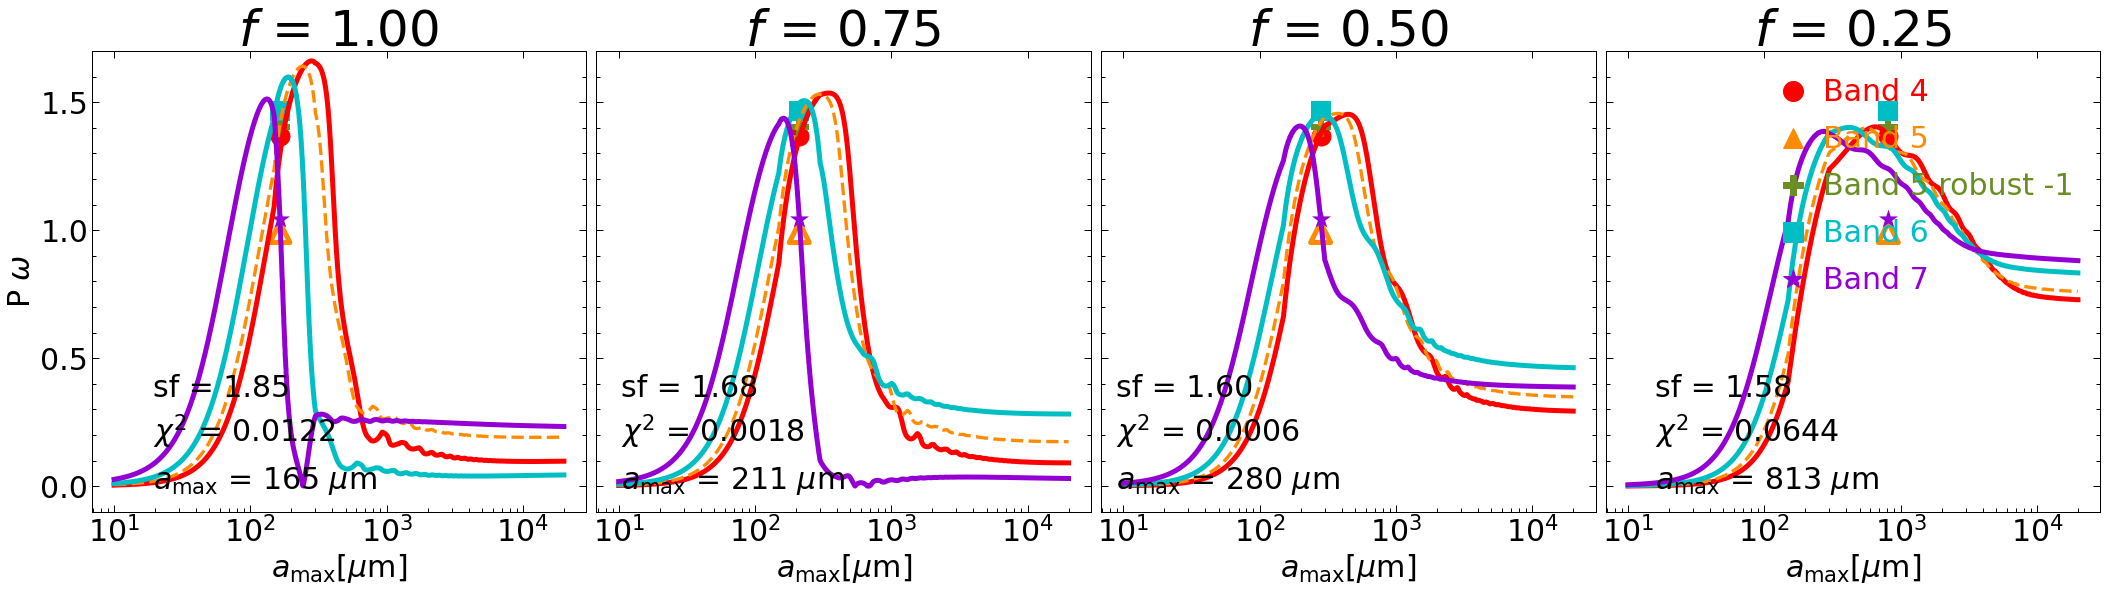

In [15]:
fig, ax = plot_scale_factor_results_JUST_AMAX(all_bands, 
                                    bands_labels, 
                                    bands_wo5, 
                                    f_values,                               
                                    a_max_dist_micron_wo5, 
                                    P_times_omega_wo5,
                                    best_sf_wo5, 
                                    best_idx_wo5,
                                    a_max_best_wo5,
                                    POLF_obs_for_plot,
                                              chi_sq_wo5,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                   chi_sq_precision = 4)
    
# Also want to plot Band 5 data 
plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_Without5.pdf", 
            dpi=300, 
            bbox_inches='tight')

# Fit and plot without 6

In [16]:
bands_wo6 = ["Band 4 nterms2", "Band 5", "Band 5 robust -1",  "Band 7 nterms2"]


a_max_dist_micron_wo6, P_times_omega_wo6, a_max_best_wo6, POLF_obs_wo6, best_sf_wo6, best_idx_wo6, chi_sq_wo6 = find_sf_v4(
    all_bands,
    bands_naming,
    bands_wo6,
    csv_files,
    P_omega_data_folder_path,
    df_POLF,
    POLF_type
)



The Bands we are looking at are: ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 7 nterms2']


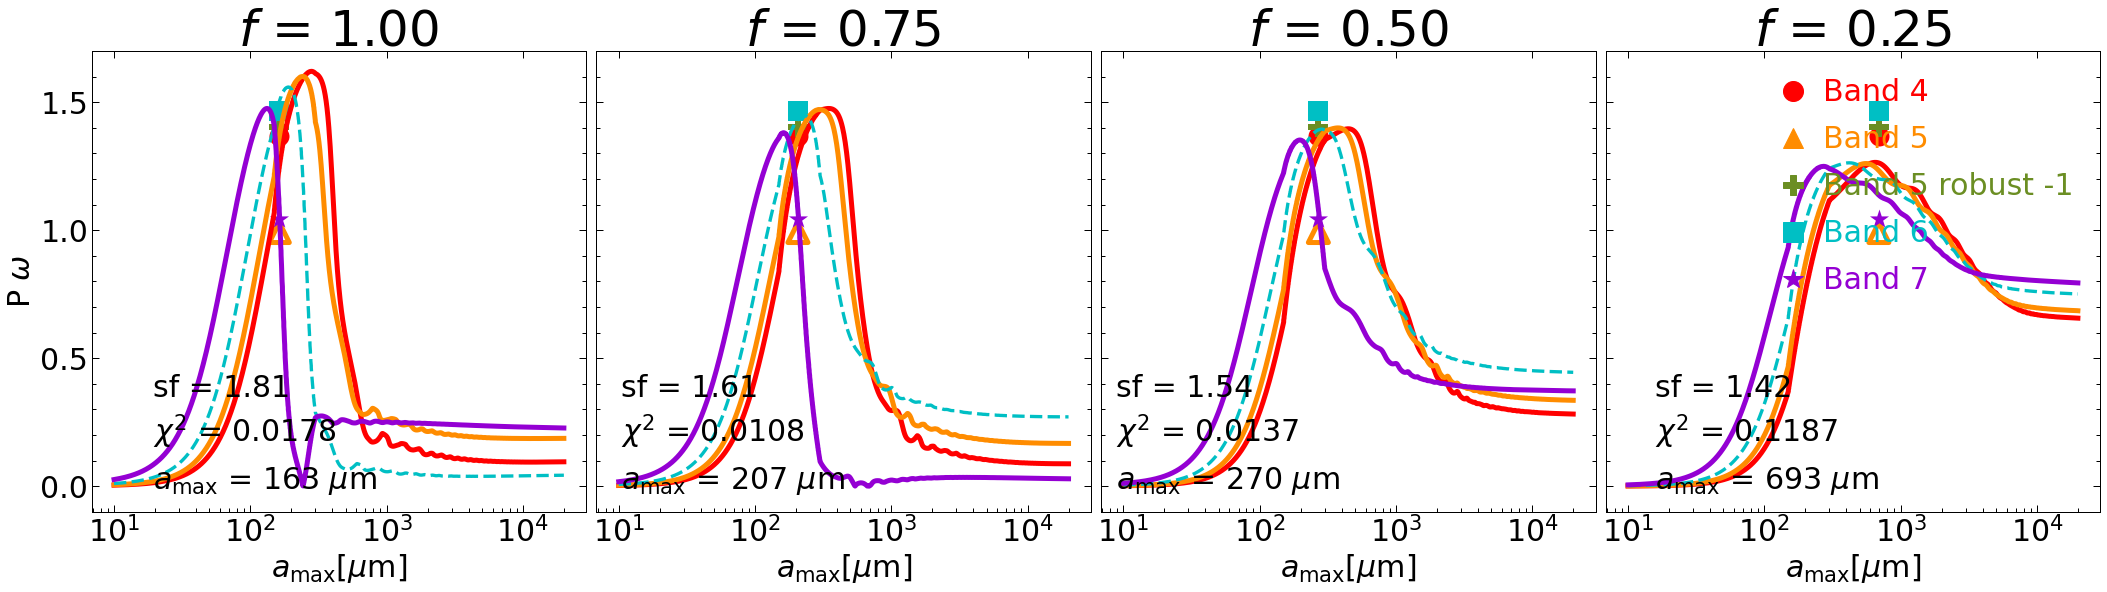

In [17]:
fig, ax = plot_scale_factor_results_JUST_AMAX(all_bands, 
                                    bands_labels, 
                                    bands_wo6, 
                                    f_values,                               
                                    a_max_dist_micron_wo6, 
                                    P_times_omega_wo6,
                                    best_sf_wo6, 
                                    best_idx_wo6,
                                    a_max_best_wo6, 
                                    POLF_obs_for_plot,
                                              chi_sq_wo6,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                   chi_sq_precision = 4)

# Also want to plot Band 6 data 
plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_Without6.pdf", 
            dpi=300, 
            bbox_inches='tight')

# Just 4 and 7

In [18]:
bands_just_47 = ["Band 4 nterms2",   "Band 7 nterms2"]


a_max_dist_micron_just_47, P_times_omega_just_47, a_max_best_just_47, POLF_obs_just_47, best_sf_just_47, best_idx_just_47, chi_sq_just_47 = find_sf_v4(
    all_bands,
    bands_naming,
    bands_just_47,
    csv_files,
    P_omega_data_folder_path,
    df_POLF,
    POLF_type,
    trouble = True,
    choose_trouble_index = True
)



The Bands we are looking at are: ['Band 4 nterms2', 'Band 5', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 7 nterms2']
The best a_max is: 212.0
At this value, the best sf is : 1.693316789641515
 
The second best a_max is: 211.367429729552
At this value, the best sf is : 1.6863477740878174
 
The third best a_max is: 212.98175465421855
At this value, the best sf is : 1.7006799441526985
 


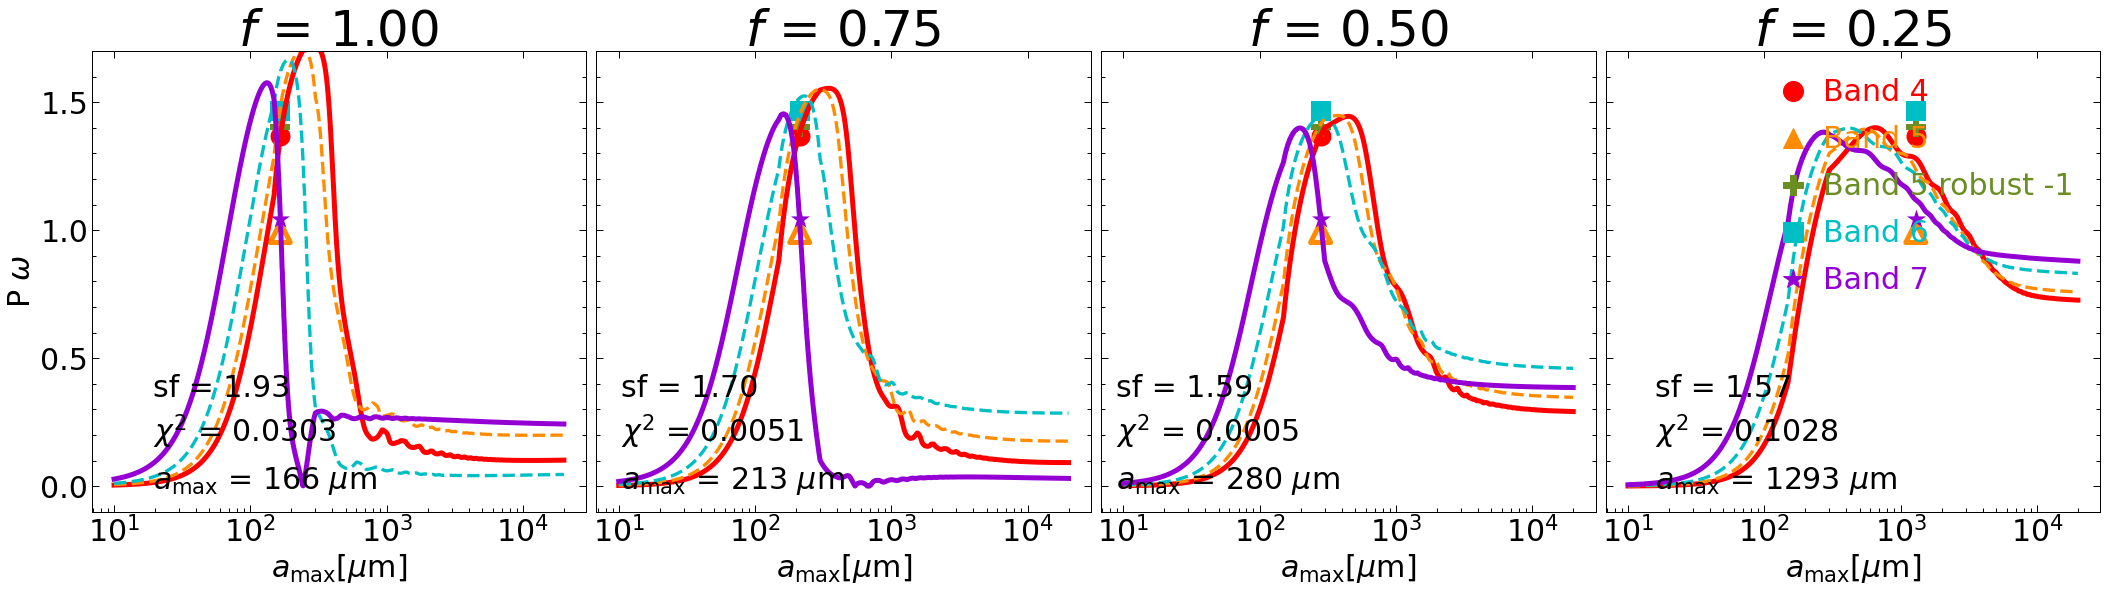

In [20]:
fig, ax = plot_scale_factor_results_JUST_AMAX(all_bands, 
                                    bands_labels, 
                                    bands_just_47, 
                                    f_values,                               
                                    a_max_dist_micron_just_47, 
                                    P_times_omega_just_47,
                                    best_sf_just_47, 
                                    best_idx_just_47,
                                    a_max_best_just_47, 
                                    POLF_obs_for_plot,
                                              chi_sq_just_47,
                                    custom_text_x = [0.075, 0, -0.02, 0.05],
                                   chi_sq_precision = 4)


plt.savefig(writeup_image_folder_path + '/DustModels/' + "DustModelPlot_Just47.pdf", 
            dpi=300, 
            bbox_inches='tight')